In [1]:
import sqlite3
import os
import json
import matplotlib.pyplot as plt
# inline plotting
%matplotlib inline

In [2]:
def get_artifact_locations(db_path, run_uid):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("SELECT artifact_uri FROM runs WHERE run_uuid = ?", (run_uid,))
    result = cursor.fetchone()
    conn.close()
    if result:
        artifact_dir_uri = result[0]
        rel_dir_uri = artifact_dir_uri.split("mlruns/")[-1]
        rel_dir_uri = "../../../mlruns/" + rel_dir_uri
        rel_file_uri_list = [os.path.join(rel_dir_uri, f) for f in os.listdir(rel_dir_uri) if os.path.isfile(os.path.join(rel_dir_uri, f))]
        return rel_file_uri_list
    else:
        raise ValueError(f"No run found with UID: {run_uid}")


In [3]:

foo = [[1, 2], [3, 4], [5, 6], [7, 8]]
list(zip(*foo))

[(1, 3, 5, 7), (2, 4, 6, 8)]

['../../../mlruns/400/04a8aaebbf08415c9468b61e4e9db840/artifacts/t=euclidean+d=25+c=3+n=08+v=1+o=100+r=199+cl=3-3-pred.json', '../../../mlruns/400/04a8aaebbf08415c9468b61e4e9db840/artifacts/t=euclidean+d=25+c=3+n=08+v=1+o=100+r=199+cl=3-3-true.json']


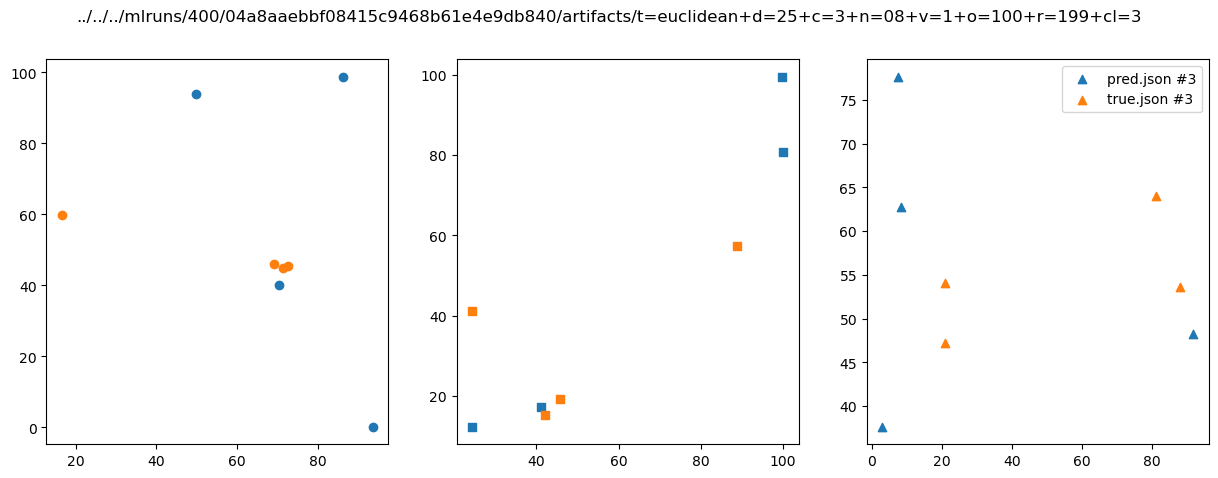

In [6]:
file_paths =get_artifact_locations('../data/experiments/cact_hpc3.db', '04a8aaebbf08415c9468b61e4e9db840')
# find all files in that directory and print their names
print(file_paths)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for file in file_paths:
    # read json file and print its content
    with open(file, 'r') as f:
        content = json.load(f)
        x, y = list(zip(*content['data']))
        # split into 3 groups of equal size
        n = len(x) // 3
        x1, y1 = x[:n], y[:n]
        x2, y2 = x[n:2*n], y[n:2*n]
        x3, y3 = x[2*n:], y[2*n:]
        axs[0].scatter(x1, y1, label=f'{file.split("-")[-1]} #1', marker='o' )
        axs[1].scatter(x2, y2, label=f'{file.split("-")[-1]} #2', marker='s' )
        axs[2].scatter(x3, y3, label=f'{file.split("-")[-1]} #3', marker='^' )   
fig.suptitle(f'{file.split("-")[0]}')
plt.legend()
plt.show()
